In [6]:
from astropy.cosmology import Planck18 as cosmo
from synthesizer.filters import FilterCollection
from synthesizer.grid import Grid
from synthpop.model import Constant, Default
from synthpop.universe import Universe
from unyt import Msun, arcminute


In [7]:
# load grid
grid = Grid("test_grid")

solid_angle = 10 * arcminute**2

model = Default()

----------
SUMMARY OF UNIVERSE
Number of galaxies: 9798
Redshift range: (0, 10.0)
----------



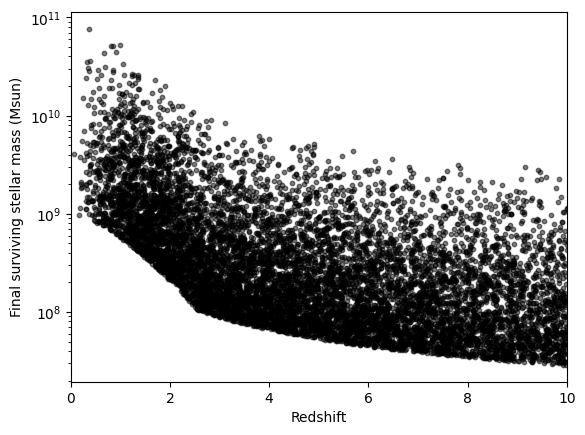

In [8]:
# Define the star formation and metallicity histories for the galaxies in the population

# Instantiate the galaxy population
universe = Universe(
    model=model,
    minimum_stellar_mass=1E9*Msun, 
    maximum_stellar_mass=1E11*Msun,
    cosmology=cosmo,
    grid=grid,
    solid_angle=solid_angle,
    random_seed=42)

print(universe)

universe.plot_redshift_surviving_mass()


## Generate and plot observed-frame photometry

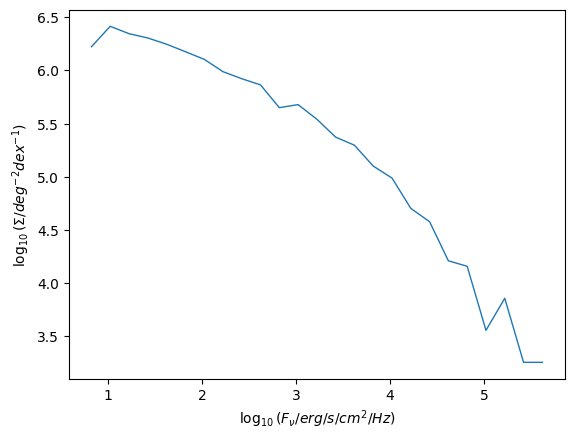

In [9]:

# Get the filter collection
filter_codes = [
    f"JWST/NIRCam.{f}"
    for f in ["F090W", "F150W", "F200W", "F277W", "F356W", "F444W"]
]

filters = FilterCollection(
    filter_codes=filter_codes,
    new_lam=grid.lam,
)

from synthesizer.emission_models import IncidentEmission

incident = IncidentEmission(grid=grid)

universe.generate_spectra(incident)

universe.generate_photometry("incident", filters)

universe.plot_number_counts("JWST/NIRCam.F150W")

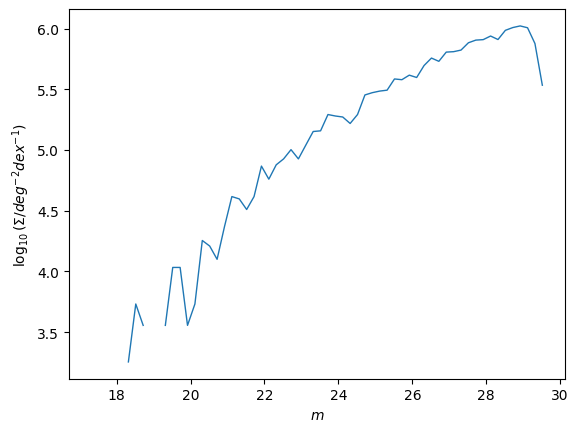

In [10]:
universe.plot_number_counts("JWST/NIRCam.F150W", magnitude=True)